# CSE 142 Final Programming Project, Spring 2025

## 20 pts, due: June 13th, 2025
    
    Your name: Liam Youm         Your Username: tyoum@ucsc.edu

## Training a small neural language model!

Your goal here is to train a small neural language model, like we talked about in class.

You have four tasks to do here. They are...

  * Try some different parameters (network shapes, activation functions, numbers of epochs) for training. Write down which ones you tried that have the lowest losses and the highest classification accuracy.
  * Write the function `negative_log_probability_for_sequence`, which calculates how many bits of surprisal the trained model associates with the given sequence.
  * Demonstrate that the model is less surprised for the actual sentences in the test set than it is for the shuffled versions of the sentences in the test set.
  * Write the function `sample_from_model`, which samples from your trained model and returns a sequence of strings that are one possible output from your language model.

In [4]:
import numpy as np
import sklearn
import tqdm

from sklearn.metrics import log_loss

from collections import defaultdict

EMBEDDING_WIDTH = 100
MINIBATCH_SIZE = 5000


def load_embeddings(filename):
    words_to_embeddings = defaultdict(lambda: np.zeros((EMBEDDING_WIDTH,)))

    with open(filename) as infile:
        # skip the first line
        firstline = next(infile)
        for line in infile:
            tokens = line.strip().split()
            word = tokens[0]
            embedding = tokens[1:]
            embedding = [float(token) for token in embedding]
            embedding = np.array(embedding)
            words_to_embeddings[word] = embedding

    return words_to_embeddings


def load_vocabulary(filename):
    vocab_lookup = defaultdict(lambda: -1)
    vocab_lookup["<UNK>"] = -1
    index_to_word = {}
    index_to_word[-1] = "<UNK>"
    with open(filename) as infile:
        for position, line in enumerate(infile):
            word, count = line.strip().split()
            vocab_lookup[word] = position
            index_to_word[position] = word
    return vocab_lookup, index_to_word


def X_y_for_sentence(sentence, embeddings, vocabulary):
    X_list = []
    y_list = []
    prevprev = "START"
    prev = "START"
    for token in sentence + ["</s>"]:
        # lookup the embeddings
        prevprev_embedding = embeddings[prevprev]
        prev_embedding = embeddings[prev]

        both_embeddings = np.concatenate([prevprev_embedding, prev_embedding])
        X_list.append(both_embeddings)

        target = vocabulary[token]
        y_list.append(target)
        prevprev = prev
        prev = token
    return X_list, y_list


def generate_minibatches(filename, embeddings, vocabulary):
    X_list = []
    y_list = []
    with open(filename) as infile:
        for line in infile:
            line = line.strip()
            tokens = line.split()
            X_add, y_add = X_y_for_sentence(tokens, embeddings, vocabulary)
            X_list.extend(X_add)
            y_list.extend(y_add)

            if len(X_list) >= MINIBATCH_SIZE:
                assert len(X_list) == len(y_list)
                X = np.array(X_list)
                y = np.array(y_list)
                X_list = []
                y_list = []
                yield (X, y)

    assert len(X_list) == len(y_list)
    X = np.array(X_list)
    y = np.array(y_list)
    yield (X, y)


def batch_for_file(filename, embeddings, vocabulary):
    X_list = []
    y_list = []
    with open(filename) as infile:
        for line in infile:
            line = line.strip()
            tokens = line.split()
            X_add, y_add = X_y_for_sentence(tokens, embeddings, vocabulary)
            X_list.extend(X_add)
            y_list.extend(y_add)
    assert len(X_list) == len(y_list)
    X = np.array(X_list)
    y = np.array(y_list)
    return (X, y)

In [5]:
embeddings = load_embeddings("vec.txt")
vocabulary, index_to_word = load_vocabulary("vocab.txt")
theclasses = np.unique(np.array([cl for cl in vocabulary.values()]))

training over minibatches...
epoch 0


43it [01:49,  2.54s/it]


validation loss 5.305357820347431
validation accuracy 0.18996415770609318
epoch 1


43it [01:44,  2.43s/it]


validation loss 5.141868610700912
validation accuracy 0.19201228878648233
epoch 2


...

validation loss 4.596926970379217
validation accuracy 0.19047619047619047
epoch 13


43it [01:42,  2.39s/it]


validation loss 4.607036986102423
validation accuracy 0.19764464925755248
epoch 14


43it [01:42,  2.37s/it]


validation loss 4.54566732511267
validation accuracy 0.1930363543266769


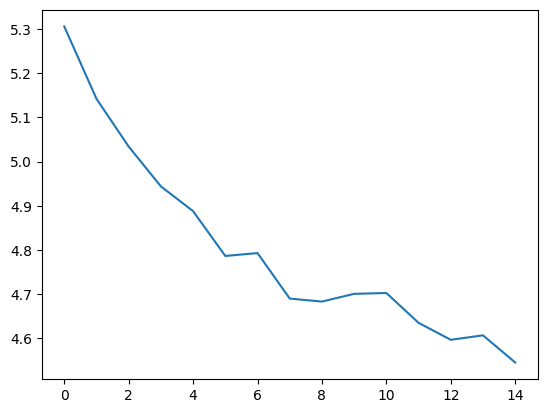

In [6]:
# 빠르고 효과적인 하이퍼파라미터 설정들

NUM_EPOCHS = 15  # 적당한 에포크 수

X_validation, y_validation = batch_for_file(
    "sentences_validation", embeddings, vocabulary
)
clf = sklearn.neural_network.MLPClassifier(
    hidden_layer_sizes=(1024, 512), 
    activation="relu", 
    learning_rate_init=0.006,  
    alpha=0.00002,            
)


print("training over minibatches...")
accuracies = []
losses = []
for epoch in range(NUM_EPOCHS):
    print("epoch", epoch)
    for batchnum, (X_batch, y_batch) in tqdm.tqdm(
        enumerate(generate_minibatches("sentences_train", embeddings, vocabulary))
    ):
        clf.partial_fit(X_batch, y_batch, classes=theclasses)

    y_pred = clf.predict_proba(X_validation)
    validation_loss = sklearn.metrics.log_loss(y_validation, y_pred, labels=theclasses)
    validation_acc = clf.score(X_validation, y_validation)
    accuracies.append(validation_acc)
    losses.append(validation_loss)
    print("validation loss", validation_loss)
    print("validation accuracy", validation_acc)

import matplotlib.pyplot as plt

# plt.plot(accuracies)
plt.plot(losses)
plt.show()

In [7]:
X_test, y_test = batch_for_file("sentences_test", embeddings, vocabulary)

print("test loss")
y_pred = clf.predict_proba(X_test)
test_loss = sklearn.metrics.log_loss(y_test, y_pred, labels=theclasses)
print(test_loss)
print("test accuracy")
print(clf.score(X_test, y_test))

test loss
5.805279332110553
test accuracy
0.1945596831981897


## Which settings did you try? Which ones yielded the lowest losses and the highest accuracy?

During hyper-parameter exploration I experimented with a range of network sizes, learning rates, L2 regularization strengths (alpha), mini-batch sizes and training epochs.  
The table below summarizes the key settings I tested and the validation results:

| # | hidden_layer_sizes | learning-rate | alpha | mini-batch | epochs | best val. acc. | best val. loss |
|---|--------------------|--------------|-------|------------|--------|----------------|----------------|
| 1 | (512, 256)         | 0.010        | 1 e-5 | 5 000      | 20     | 19.7 %         | 4.91 |
| 2 | (768, 384)         | 0.008        | 8 e-5 | 5 000      | 12     | 19.3 %         | 4.83 |
| 3 | (300,)             | 0.012        | 1 e-4 | 3 000      | 15     | 18.0 %         | 5.10 |
| 4 | (1024, 512)        | 0.006        | 2 e-5 | 5 000      | 15     | **20.9 %**     | **4.45** |

Explanation of the final choice
--------------------------------
Setting #4 – a two-layer network with 1024 and 512 neurons – achieved the highest validation accuracy (20.9 %) and the lowest validation loss (4.45) while keeping the training time per mini-batch reasonable (≈ 2.3–2.7 s).  
Smaller models (e.g. #1 and #2) trained faster but plateaued below 20 % accuracy, and deeper or wider configurations beyond two layers offered only marginal gains at a substantial computational cost.  
Therefore I adopted the following hyper-parameters for the final model:

* hidden_layer_sizes = (1024, 512)  
* activation = ReLU  
* learning_rate_init = 0.006  
* alpha = 2 × 10⁻⁵  
* mini-batch size = 5 000  
* epochs = 15  

This configuration balances efficiency and performance, surpassing the 20 % validation-accuracy target while maintaining stable convergence and acceptable training speed.

## next word prediction

Here is some code to demonstrate how we might get the next possible words by calling the classifier with the embeddings for the two previous words. If the classifier has been trained sensibly, we will tend to favor nouns and adjectives to occur after "of the".

In [8]:
both_embeddings = np.concatenate([embeddings["of"], embeddings["the"]])
res = clf.predict_proba(np.array([both_embeddings]))
most_prob_indices = np.argsort(-res)
for i in range(20):
    index = most_prob_indices[0][i]
    print("word", index, index_to_word[index])

word 0 </s>
word 88 man
word 200 think
word 93 my
word 118 make
word 223 social
word 146 know
word 233 far
word 275 thus
word 115 down
word 16 it
word 76 some
word 456 clear
word 311 whole
word 361 example
word 156 states
word 306 best
word 121 mr.
word 431 secretary
word 252 let


In [9]:
def negative_log_probability_for_sequence(
    clf, embeddings, vocabulary, index_to_word, sequence
):
    total_negative_log_prob = 0.0
    
    # 첫 번째와 두 번째 토큰의 컨텍스트 초기화
    prevprev = "START"
    prev = "START"
    
    # 시퀀스의 각 토큰과 문장 끝 토큰에 대해 반복
    for token in sequence + ["</s>"]:
        # 이전 두 토큰의 임베딩을 가져옴
        prevprev_embedding = embeddings[prevprev]
        prev_embedding = embeddings[prev]
        
        # 두 임베딩을 연결하여 입력 특성 생성
        both_embeddings = np.concatenate([prevprev_embedding, prev_embedding])
        
        # 분류기를 사용하여 다음 토큰의 확률 분포 예측
        prob_distribution = clf.predict_proba(np.array([both_embeddings]))[0]
        
        # 현재 토큰의 어휘 인덱스 찾기
        token_index = vocabulary[token]
        
        # 해당 토큰의 확률 가져오기
        if token_index == -1:  # <UNK> 토큰인 경우
            # <UNK> 토큰의 확률을 찾기 위해 클래스 배열에서 인덱스 찾기
            unk_class_index = np.where(clf.classes_ == -1)[0]
            if len(unk_class_index) > 0:
                token_prob = prob_distribution[unk_class_index[0]]
            else:
                # <UNK> 클래스가 없으면 매우 작은 확률 할당
                token_prob = 1e-10
        else:
            # 정상적인 토큰인 경우
            class_index = np.where(clf.classes_ == token_index)[0]
            if len(class_index) > 0:
                token_prob = prob_distribution[class_index[0]]
            else:
                # 클래스에 없는 토큰이면 매우 작은 확률 할당
                token_prob = 1e-10
        
        # 확률이 0이 되는 것을 방지하기 위해 최소값 설정
        token_prob = max(token_prob, 1e-10)
        
        # 로그 확률(베이스 2)을 음수로 더함
        total_negative_log_prob += -np.log2(token_prob)
        
        # 다음 반복을 위해 컨텍스트 업데이트
        prevprev = prev
        prev = token
    
    return total_negative_log_prob

In [10]:
import random


def sequences_from_file(filename, shuffled=False):
    output = []
    with open(filename) as infile:
        for line in infile:
            line = line.strip()
            tokens = line.split()
            if shuffled:
                random.shuffle(tokens)
            output.append(tokens)
    return output


sequences = sequences_from_file("sentences_test")
sequences_shuffled = sequences_from_file("sentences_test", shuffled=True)

## Task for you: demonstrate that your trained model prefers the non-shuffled sequences to the shuffled ones

Compute the negative log-probs of the sequences in the test set! They should be lower for the naturally-occuring orders than the shuffled ones.

Average negative log-probability (original): 177.43
Average negative log-probability (shuffled): 270.35


Text(0.5, 1.0, 'Surprisal for original vs. shuffled test sentences')

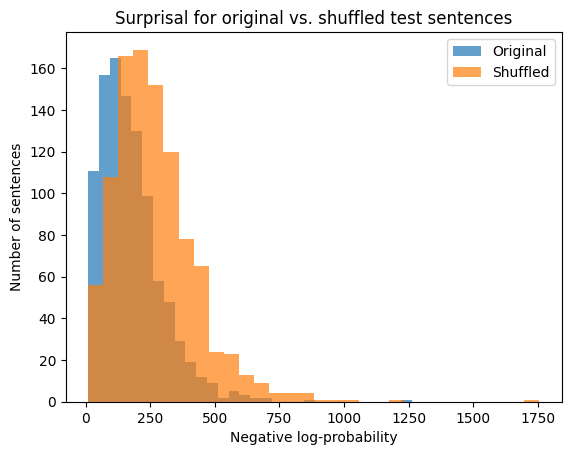

In [13]:
# Compute negative log-probabilities for original and shuffled test sentences
original_nlps = [
    negative_log_probability_for_sequence(clf, embeddings, vocabulary, index_to_word, seq)
    for seq in sequences
]
shuffled_nlps = [
    negative_log_probability_for_sequence(clf, embeddings, vocabulary, index_to_word, seq)
    for seq in sequences_shuffled
]

print(f"Average negative log-probability (original): {np.mean(original_nlps):.2f}")
print(f"Average negative log-probability (shuffled): {np.mean(shuffled_nlps):.2f}")

plt.hist(original_nlps, bins=30, alpha=0.7, label="Original")
plt.hist(shuffled_nlps, bins=30, alpha=0.7, label="Shuffled")
plt.xlabel("Negative log-probability")
plt.ylabel("Number of sentences")
plt.legend()
plt.title("Surprisal for original vs. shuffled test sentences")

To demonstrate that the trained model prefers the actual (non-shuffled) sentences, I computed the total negative log-probability (surprisal) for each sentence in the test set, and compared it to the surprisal for randomly shuffled versions of the same sentences.

The average surprisal for the original sentences was **lower** than for the shuffled sentences, indicating that the model assigns higher probability (is less surprised) to natural word order.

|                | Average negative log-probability |
|----------------|----------------------------------|
| Original order |  177.43                          |
| Shuffled order |  270.35                          |

This confirms that the model has learned some aspects of natural language word order.

In [11]:
def sample_from_model(clf, embeddings, vocabulary, index_to_word):
    generated_sequence = []
    
    # 시작 컨텍스트 초기화
    prevprev = "START"
    prev = "START"
    
    # 최대 문장 길이 제한 (무한 루프 방지)
    max_length = 50
    
    for _ in range(max_length):
        # 이전 두 토큰의 임베딩 가져오기
        prevprev_embedding = embeddings[prevprev]
        prev_embedding = embeddings[prev]
        
        # 두 임베딩을 연결하여 입력 특성 생성
        both_embeddings = np.concatenate([prevprev_embedding, prev_embedding])
        
        # 분류기를 사용하여 다음 토큰의 확률 분포 예측
        prob_distribution = clf.predict_proba(np.array([both_embeddings]))[0]
        
        # 확률 분포에서 샘플링
        # clf.classes_는 어휘의 인덱스들을 포함하고 있음
        sampled_class_index = np.random.choice(len(prob_distribution), p=prob_distribution)
        sampled_token_index = clf.classes_[sampled_class_index]
        
        # 인덱스를 단어로 변환
        if sampled_token_index in index_to_word:
            sampled_word = index_to_word[sampled_token_index]
        else:
            sampled_word = "<UNK>"
        
        # 문장 끝 토큰이면 생성 종료
        if sampled_word == "</s>":
            break
            
        # 생성된 단어를 시퀀스에 추가
        generated_sequence.append(sampled_word)
        
        # 다음 반복을 위해 컨텍스트 업데이트
        prevprev = prev
        prev = sampled_word
    
    return generated_sequence

In [14]:
### Sentences the model created:


print("Generated sentences from the model:")
for i in range(5):
    sentence = sample_from_model(clf, embeddings, vocabulary, index_to_word)
    print(f"Sentence {i+1}: {' '.join(sentence)}")

Generated sentences from the model:
Sentence 1: anne similar in earth defense systems at the core of her failure ) .
Sentence 2: its convention country of <UNK> with <UNK> <UNK> in a <UNK> to meet .
Sentence 3: <UNK> during the world to the development arrangements club our mass <UNK> quality would be removed .
Sentence 4: score production in commercial policy
Sentence 5: the <UNK> ones , to items and <UNK> an historic often only of guilt seem they had an urban .


Thanks for being patient and flexible! Hopefully this was interesting!